# Ammonia synthesis in a membrane reactor — paper figures and dataset

This notebook runs every case behind the paper and generates every simulation
figure. Its data points **are** the published dataset.

It is a thin driver over `reactor.paper`, a cached pipeline package: each cell
is one function call, every solved case is cached on disk, and the runner skips
cases whose cache is complete. Re-running from a clean kernel therefore takes
seconds and never depends on volatile kernel state.

**Long sweeps do not belong in this notebook.** Run them as a background script

```
nohup python -u -m scripts.run_paper_sweep --resolution publication \
    > sweep_publication.log 2>&1 &
```

and let the cells below hit the cache.

| section | figures |
|---|---|
| Weisz–Prater criterion | 2 |
| Kinetics validation | 3, 4 |
| Membrane permeance validation | 5 |
| 1D vs 2D KPI sweeps | 6, 7, 8 |
| 2D fields and CP profiles | 9, 10, 11 |
| Sherwood correlation and profiles | 12, 13, 14 |
| Corrected CP per κ group | 15 |
| Mechanistic CP closure | 16 |

Figure 1 (the reactor schematic) is hand-drawn and is not this notebook's job.

## Run on Google Colab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/computational-chemical-engineering/ammonia_synthesis_reactor/blob/main/notebooks/paper_figures.ipynb)

The next cell is a **no-op on a local checkout**. On Colab it installs this
package (pulling `pymrm` from PyPI), downloads the archived dataset — its
DOI and download URL live in `reactor.archive`, filled in at deposit
time — verifies it against its SHA-256 manifest and unpacks it into the local cache. Every
cell below then re-renders from cache, exactly as on a machine that ran
the sweeps.

In [1]:
# ── Google Colab bootstrap (no-op on a local checkout) ───────────────────────
import os

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB:
    os.environ["REACTOR_RESOLUTION"] = "publication"   # the archived tier
    if not os.path.exists("data/inputs"):
        !git clone --depth 1 https://github.com/computational-chemical-engineering/ammonia_synthesis_reactor.git
        %cd ammonia_synthesis_reactor
    %pip install -q .
    # The archive identifiers live in one place, reactor.archive, so a
    # deposit is filled in once and every consumer follows.
    from reactor import archive
    if not os.path.exists("dataset/manifest.json"):
        DATASET_ZIP_URL = archive.dataset_zip_url()   # raises while pending
        !wget -q -O _dataset.zip "$DATASET_ZIP_URL"
        !unzip -q -o _dataset.zip
    from reactor.paper import dataset
    check = dataset.verify()                 # checksums vs manifest.json
    assert check["ok"], check
    print(f"dataset verifies: {check['n_checked']} files")
    print(dataset.restore_cache())           # populate the cache; never overwrites

## 1. Settings

`RESOLUTION` trades accuracy for wall time:

| | draft | publication |
|---|---|---|
| grid (num_r × num_z) | 24 × 60 | 40 × 100 |
| `steady_state_atol` (weighted wrms) | 1.0 | 1.0 |
| 2D sweep, expected | ~20–30 min | well under 2 h |
| purpose | reviewers, CI, iteration | the paper + dataset |

Accuracy context, measured at floor-converged states: relative to the
publication grid the draft grid shifts NH₃ production by ≤ 0.2 % for most
families but by **~8 % for the low-GHSV G1 cases**, and NH₃ recovery by ~3 %
everywhere. Draft figures are for reading trends, not for quoting numbers.

**On tolerances** *(rework of 2026-08-17, `the solver's stopping rules`).*
The stopping test is the error-weighted RMS residual norm (CVODE convention):
`wrms ≤ 1` with per-block rtol/atol for the concentration, pressure and
temperature rows, and "converged" additionally requires the outlet KPIs to be
stagnant. One tolerance now means the same thing on both grids. A case whose
residual floor sits above the tolerance stops at its floor with stagnant KPIs
and is accepted as **`floored`** — a converged iteration against an
unreachable threshold, carrying a per-case `convergence_certificate`
(20-step KPI drift) in its `kpis.json`. Genuinely non-stationary cases (the
598 K multiplicity window) are classified **`oscillatory`**, solved to their
dynamically unstable steady state by temperature continuation, and carry an
eigenvalue certificate.


In [2]:
import os

RESOLUTION = os.environ.get("REACTOR_RESOLUTION", "draft")   # "draft" | "publication"
FORCE_RERUN = False         # ignore the cache

### Configuration switches

Reporting-level choices sit behind named switches in
`reactor.paper.settings`; flipping one is a one-line change plus a
re-render (never a re-compute):

| switch | meaning | default |
|---|---|---|
| `ONE_D_VARIANT` / `ONE_D_CORRECTED_VARIANT` | which 1D model variants are published | plain 1D, Sherwood-corrected 1D |
| `INCLUDE_598K` | how the two dynamically-delicate 598 K cases enter the **figures** (`"exclude"` / `"include"` / `"section"`); they are always solved, cached and shipped in the dataset | `"exclude"` |
| `PERMEATION_EXP_CSV` | source of Figure 5's experimental permeance points (see the CSV header for provenance) | measured laboratory values |
| `S1_DIFFUSION_DATA_CSV` | digitized literature diffusivity points of SI Figure S.1 | `data/inputs/s1_diffusivity_chapman.csv` |
| `WHSV_CONVENTION` | convention of the stored per-case WHSV column (figures label the axis GHSV [h⁻¹] directly) | `"archived"` |

In [3]:
from reactor.paper import cache, cases, figures, kpis, provenance, runner, settings

res = settings.resolution(RESOLUTION)
print(f"resolution    {res.name}: {res.num_r}x{res.num_z}, atol={res.steady_state_atol:g}")
print(f"pressure row  {settings.PRESSURE_EQUATION}")
print(f"1D variants   {settings.ONE_D_VARIANT}, {settings.ONE_D_CORRECTED_VARIANT}")
print(f"598 K cases   INCLUDE_598K = {settings.INCLUDE_598K!r}")
print(f"space velocity: figures use GHSV [1/h]; stored WHSV column convention = {settings.WHSV_CONVENTION!r}")
print()
print(provenance.describe())

resolution    draft: 24x60, atol=1
pressure row  eos
1D variants   membrane_reactor_1d, membrane_reactor_1d_corrected
598 K cases   INCLUDE_598K = 'exclude'
space velocity: figures use GHSV [1/h]; stored WHSV column convention = 'archived'

commit 583d4c8805 (dirty) on main | python 3.13.5 | h5py 3.16.0, matplotlib 3.11.1, numpy 2.4.6, openpyxl 3.1.5, pandas 3.0.5, pymrm 2.3.1.dev3+g93eeaefb4, scipy 1.18.0


## 2. Case tables

Source of truth is `data/inputs/cases_to_run.xlsx` (families G1–G8, 52
cases). When a local copy of the originally archived dataset is present
(`Dataset_paper/`, not part of this repository), the reconstructed
configurations are additionally cross-checked against its per-case
`config.json` files; disagreements are reported rather than silently
patched. Without the archive the check is skipped.

In [4]:
case_table = cases.load_case_table()
by_id = case_table.set_index("Case_ID")

print(f"{len(case_table)} cases, families {sorted(case_table['family'].unique())}")
print(f"D3={settings.INCLUDE_598K!r} -> {len(cases.select_cases(case_table))} cases in figures/dataset")
case_table.groupby("family").size().rename("cases").to_frame().T

52 cases, families ['G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8']
D3='exclude' -> 50 cases in figures/dataset


family,G1,G2,G3,G4,G5,G6,G7,G8
cases,8,8,5,5,7,7,6,6


In [5]:
# Cross-check the reconstructed configs against the archive: one case per
# family, plus both 598 K cases (whose archived runs never converged).
probe = [case_table[case_table["family"] == f]["Case_ID"].iloc[0]
         for f in sorted(case_table["family"].unique())]
probe += list(settings.CASES_598K)

report = cases.crosscheck_report(
    probe, lambda cid: runner.build_config_2d(by_id.loc[cid].rename(cid), RESOLUTION)[0]
)
mismatches = report[report["status"] == "MISMATCH"]
print(f"{(report['status'] == 'match').sum()}/{len(probe)} configs match the archive exactly")
if not mismatches.empty:
    print("DISCREPANCY — the archived config wins; investigate before running the sweep:")
    display(mismatches)

10/10 configs match the archive exactly


## 3. 2D sweep

All 52 cases, cold starts, EOS pressure row, at `RESOLUTION`. Both 598 K cases
are always solved (they reach their steady state through the
temperature-continuation ladder, ~15–30 min each) regardless of the `INCLUDE_598K` reporting switch.

If the cache is cold, run the background script rather than this cell:

```
python -u -m scripts.run_paper_sweep --resolution draft
```

In [6]:
status = cache.status_table(RESOLUTION, settings.MODEL_2D, case_table["Case_ID"].tolist())
print(f"cached: {int(status['cached'].sum())}/{len(status)} | "
      f"total solve time {status['runtime_s'].sum() / 60:.1f} min")
status[~status["cached"]][["Case_ID"]] if (~status["cached"]).any() else "cache complete"

cached: 52/52 | total solve time 35.8 min


'cache complete'

In [7]:
summary_2d = runner.run_sweep(case_table, RESOLUTION, force=FORCE_RERUN, verbose=1)
summary_2d["status"].value_counts()

[1/52] G1 — GHSV sweep_50 (cached)


[2/52] G1 — GHSV sweep_500 (cached)


[3/52] G1 — GHSV sweep_1000 (cached)


[4/52] G1 — GHSV sweep_3000 (cached)


[5/52] G1 — GHSV sweep_5000 (cached)


...

[50/52] G8 — Radius sweep (high GHSV)_0.045 (cached)


[51/52] G8 — Radius sweep (high GHSV)_0.05 (cached)


[52/52] G8 — Radius sweep (high GHSV)_0.06 (cached)



52/52 accepted, 0 not yet cached -> results/paper/draft/summary_kpis_2d.csv


status
converged          42
flagged_balance     8
floored             2
Name: count, dtype: int64

Sanity checks on the sweep: elemental balance closure, the CP metric, and the
598 K pair. `flagged_balance` means the case converged but its elemental
balance sits outside 1e-3 relative — worth watching, not a failure.

In [8]:
view = summary_2d[["Case_ID", "family", "status", "steady_state_norm",
                   "NH3_prod_out", "X_H2_out", "NH3_rec_out", "CP_min",
                   "balance_H_rel", "balance_N_rel", "runtime_s"]]

failed = summary_2d[summary_2d["status"] == "failed"]
if not failed.empty:
    print(f"{len(failed)} case(s) FAILED — figures reading their fields cannot be drawn:")
    for _, r in failed.iterrows():
        print(f"  {r['Case_ID']}: {r.get('message')}")
    print()

print("598 K cases (always solved; INCLUDE_598K controls only whether they are shown):")
display(view[view["Case_ID"].isin(settings.CASES_598K)])
view

598 K cases (always solved; INCLUDE_598K controls only whether they are shown):


,Case_ID,family,status,steady_state_norm,NH3_prod_out,X_H2_out,NH3_rec_out,CP_min,balance_H_rel,balance_N_rel,runtime_s
28,G5 — Temperature sweep_598,G5,converged,0.101588,34.481058,20.519359,10.832848,0.678793,4.410988e-08,1.417587e-08,151.550736
35,G6 — Temperature sweep598,G6,converged,0.485736,38.566656,22.948814,37.706526,0.648508,1.851646e-05,4.724995e-06,15.515274


,Case_ID,family,status,steady_state_norm,NH3_prod_out,X_H2_out,NH3_rec_out,CP_min,balance_H_rel,balance_N_rel,runtime_s
0,G1 — GHSV sweep_50,G1,flagged_balance,0.247877,0.993244,57.117659,99.800083,0.566092,1.989412e-02,7.533948e-03,446.959834
1,G1 — GHSV sweep_500,G1,flagged_balance,0.330610,5.469440,32.296226,68.878982,0.650683,2.519105e-03,8.970341e-04,28.689782
2,G1 — GHSV sweep_1000,G1,converged,0.162990,8.539345,25.375120,45.112665,0.677528,3.331139e-04,9.713527e-05,19.515135
3,G1 — GHSV sweep_3000,G1,converged,0.106799,19.141803,18.985188,19.283852,0.727941,7.279087e-11,3.956477e-10,18.800238
4,G1 — GHSV sweep_5000,G1,converged,0.140480,31.908797,18.987820,12.182199,0.732910,8.137289e-06,2.011584e-06,14.212614
5,G1 — GHSV sweep_10000,G1,converged,0.342969,62.291762,18.531681,6.210798,0.748570,2.949094e-05,7.264386e-06,14.118181
6,G1 — GHSV sweep_30000,G1,converged,0.249517,183.275250,18.177571,1.466462,0.710006,8.021861e-09,2.385554e-10,17.240637
7,G1 — GHSV sweep_60000,G1,converged,0.217198,170.983819,8.479808,0.518823,0.670531,5.649052e-06,1.417102e-06,4.491377
8,G2 — GHSV sweep_50,G2,flagged_balance,0.565377,0.864409,51.357873,99.926334,0.618020,8.229671e-04,1.168741e-02,62.818042
9,G2 — GHSV sweep_500,G2,converged,0.530806,7.651446,45.522656,98.538629,0.704898,1.040496e-04,4.716749e-04,63.278672


The manuscript's Figure 9 states that CP < 1 everywhere in 48 cases. That is a
claim about the *maximum* of CP over the membrane-active length, so testing it
needs `CP_max` — the cached `CP_min` alone would make it trivially true.

In [9]:
cp = runner.cp_extremes(case_table, RESOLUTION)
n_below = int(cp["CP_below_1_everywhere"].sum())
print(f"CP < 1 everywhere in {n_below} of {len(cp)} solved cases "
      f"(the paper says 48); global CP range "
      f"[{cp['CP_min'].min():.3f}, {cp['CP_max'].max():.3f}]")
cp[~cp["CP_below_1_everywhere"]]

CP < 1 everywhere in 48 of 52 solved cases (the paper says 48); global CP range [0.479, 1.060]


,Case_ID,CP_min,CP_max,CP_below_1_everywhere
8,G2 — GHSV sweep_50,0.618020,1.056814,False
27,G5 — Temperature sweep_573,0.589920,1.060138,False
40,G7 — Radius sweep (low GHSV)_0.02,0.713685,1.059194,False
41,G7 — Radius sweep (low GHSV)_0.03,0.665266,1.048929,False


### Comparison against the archived dataset (optional)

Runs only when a local copy of the originally archived `summary_kpis_2d.csv`
is present. Its two unconverged 598 K rows are excluded. At draft resolution
the expected disagreement is a few percent — up to ~8 % for the low-GHSV G1
cases; at publication resolution it is within solver-tolerance noise (~1 %).

In [10]:
archived_csv = settings.archive_root() / "summary_kpis_2d.csv"
if archived_csv.exists():
    delta = kpis.compare_to_archive(summary_2d, archived_csv)
    display(delta.set_index("Case_ID").describe().T[["mean", "50%", "max"]])
    display(delta.set_index("Case_ID").sort_values("NH3_prod_out_rel", ascending=False).head(8))
else:
    print(f"archive not available at {archived_csv} — skipping comparison")

,mean,50%,max
X_H2_out_rel,0.166531,0.003662,1.699607
NH3_prod_out_rel,0.118062,0.006344,0.932169
NH3_rec_out_rel,0.176853,0.029145,2.839114
NH3_yield_out_rel,0.156286,0.006344,1.665820
NH3_purity_out_rel,0.360758,0.027354,6.082427
DeltaT_max_rel,0.047651,0.007728,0.394043


,X_H2_out_rel,NH3_prod_out_rel,NH3_rec_out_rel,NH3_yield_out_rel,NH3_purity_out_rel,DeltaT_max_rel
Case_ID,,,,,,
G7 — Radius sweep (low GHSV)_0.02,0.364557,0.932169,0.078454,0.356622,0.195336,0.226020
G7 — Radius sweep (low GHSV)_0.03,0.920082,0.905006,0.414432,0.899880,1.004256,0.079115
G7 — Radius sweep (low GHSV)_0.04,1.339811,0.883932,1.016831,1.321368,2.318521,0.224824
G7 — Radius sweep (low GHSV)_0.045,1.483820,0.876612,1.402531,1.467769,3.141670,0.263357
G7 — Radius sweep (low GHSV)_0.05,1.566646,0.873133,1.881891,1.537343,4.057167,0.298975
G7 — Radius sweep (low GHSV)_0.06,1.699607,0.866709,2.839114,1.665820,6.082427,0.319915
G1 — GHSV sweep_50,0.192148,0.152382,0.000419,0.152381,0.092467,0.028896
G1 — GHSV sweep_500,0.019023,0.062305,0.094826,0.062305,0.024846,0.088618


## 4. 1D sweeps and the corrected closure

Two 1D variants ship with the paper:

* **plain 1D** (`membrane_reactor_1d`): CP = 1, bulk-driven permeation — the
  baseline whose deviation from 2D motivates the paper.
* **corrected 1D** (`membrane_reactor_1d_corrected`): a film-resistance
  closure `Sh = coeff · κ^exp` with **κ = r_mem/r_max**, refit below against
  the certified 2D dataset; the coefficients live in the cached fit file, not
  in code, so a refit invalidates the corrected-1D cache automatically.
* a third, mechanistic **screened** closure (`cp_closure="screened"`) is kept
  as a chemistry-portable alternative and appears in Figure 15.

The exact-tracing cell below closes the loop: with the flux-matched k_cp
extracted from a 2D case, the corrected 1D reproduces that case's recovery to
a fraction of a percent — the remaining 1D–2D gap is the thermal closure.

In [11]:
from reactor.paper import closures

fit = closures.fit_sh_kappa(case_table, RESOLUTION)
print(f"Sh = {fit['coeff']:.3f} * kappa^({fit['exp']:.3f})   (kappa = r_mem/r_max)")
print(f"pooled R^2 = {fit['r_squared_pooled']:.3f} over {fit['n_kappa_groups']} kappa groups, "
      f"{fit['n_cases']} cases")
for g in fit["pooled"]:
    print(f"  kappa={g['kappa']:.4f}  Sh={g['Sh_group']:7.2f}  n={g['count']:2d}  std(lnSh)={g['std']:.3f}")

Sh = 1.463 * kappa^(-0.939)   (kappa = r_mem/r_max)
pooled R^2 = 0.991 over 6 kappa groups, 52 cases
  kappa=0.0833  Sh=  15.16  n=22  std(lnSh)=0.161
  kappa=0.1000  Sh=  12.86  n= 2  std(lnSh)=0.121
  kappa=0.1111  Sh=  11.67  n= 2  std(lnSh)=0.085
  kappa=0.1250  Sh=  10.29  n= 2  std(lnSh)=0.070
  kappa=0.1667  Sh=   7.37  n=22  std(lnSh)=0.172
  kappa=0.2500  Sh=   5.58  n= 2  std(lnSh)=0.139


In [12]:
# Both 1D sweeps (seconds per case; hits the cache when already run).
summary_1d = runner.run_sweep(case_table, RESOLUTION, model=settings.MODEL_1D,
                              force=FORCE_RERUN, verbose=1)
summary_1dc = runner.run_sweep(case_table, RESOLUTION, model=settings.MODEL_1D_CORRECTED,
                               force=FORCE_RERUN, verbose=1)
summary_1ds = runner.run_sweep(case_table, RESOLUTION, model=settings.MODEL_1D_SCREENED,
                               force=FORCE_RERUN, verbose=1)

[1/52] G1 — GHSV sweep_50 (cached)


[2/52] G1 — GHSV sweep_500 (cached)


[3/52] G1 — GHSV sweep_1000 (cached)


[4/52] G1 — GHSV sweep_3000 (cached)


[5/52] G1 — GHSV sweep_5000 (cached)


...

[49/52] G8 — Radius sweep (high GHSV)_0.04 (cached)


[50/52] G8 — Radius sweep (high GHSV)_0.045 (cached)


[51/52] G8 — Radius sweep (high GHSV)_0.05 (cached)


[52/52] G8 — Radius sweep (high GHSV)_0.06 (cached)



52/52 accepted, 0 not yet cached -> results/paper/draft/summary_kpis_1d_screened.csv


### Exact-tracing validation

The corrected 1D model run with the per-case flux-matched k_cp override
carries the 2D species closure by construction, so whatever gap remains
measures everything the species closure does *not* explain (the thermal
closure, axial dispersion, reaction-rate averaging). Measured on G2_3000:
NH₃ recovery within 0.2% of 2D, X_H₂ within 1.5%, while ΔT_max stays ~9%
off — the 1D-vs-2D difference decomposes into a species part (closed by the
Sherwood correction) and a thermal part (not modelled by it).

In [13]:
import pandas as pd

TRACE_CASES = ["G2 — GHSV sweep_50", "G2 — GHSV sweep_3000",
               "G7 — Radius sweep (low GHSV)_0.02", "G8 — Radius sweep (high GHSV)_0.06"]
by_id = case_table.set_index("Case_ID", drop=False)
trace = pd.DataFrame([
    runner.trace_case_1d(by_id.loc[cid], RESOLUTION) for cid in TRACE_CASES
])
trace[[c for c in trace.columns if c == "Case_ID" or c.endswith("_rel_err")]]

,Case_ID,X_H2_out_rel_err,NH3_prod_out_rel_err,NH3_rec_out_rel_err,NH3_purity_out_rel_err,DeltaT_max_rel_err
0,G2 — GHSV sweep_50,0.000828,0.000379,0.000099,0.000708,0.108960
1,G2 — GHSV sweep_3000,0.029692,0.035861,0.003944,0.029941,0.105118
2,G7 — Radius sweep (low GHSV)_0.02,0.015543,0.015761,0.000098,0.017573,0.089298
3,G8 — Radius sweep (high GHSV)_0.06,0.004007,0.004474,0.001385,0.003066,0.114829


### 2D vs 1D vs corrected 1D, per family

The table behind Figures 6–8: family-median relative deviation of each 1D
variant from the certified 2D KPIs.

In [14]:
kpi_cols = ["X_H2_out", "NH3_prod_out", "NH3_rec_out", "NH3_purity_out"]
m = summary_2d.merge(summary_1d, on="Case_ID", suffixes=("_2d", "_1d")) \
              .merge(summary_1dc[["Case_ID", *kpi_cols]].rename(
                  columns={k: f"{k}_1dc" for k in kpi_cols}), on="Case_ID") \
              .merge(summary_1ds[["Case_ID", *kpi_cols]].rename(
                  columns={k: f"{k}_1ds" for k in kpi_cols}), on="Case_ID")
rows = []
for k in kpi_cols:
    for tag in ("1d", "1dc", "1ds"):
        rel = (m[f"{k}_{tag}"] - m[f"{k}_2d"]).abs() / m[f"{k}_2d"].abs()
        rows.append({"KPI": k, "model": tag,
                     "median_rel_dev_%": 100 * rel.median(),
                     "max_rel_dev_%": 100 * rel.max()})
pd.DataFrame(rows).pivot(index="KPI", columns="model").round(2)

median_rel_dev_%             max_rel_dev_%              
model                        1d   1dc   1ds            1d    1dc    1ds
KPI                                                                    
NH3_prod_out               4.89  1.02  1.12         31.11  14.75  11.39
NH3_purity_out            75.58  5.00  5.65        213.40  31.28  43.06
NH3_rec_out               67.82  2.34  4.59        199.77  18.29  42.47
X_H2_out                   5.11  1.08  1.13         31.02  14.67  11.31

## 5. Figures 6–8 — 1D vs 2D KPI sweeps

Six KPI panels per figure (conversion, production, recovery, yield, purity,
ΔT_max), 2D solid, 1D dashed, across the GHSV, pressure and radius sweeps.
ΔT_max compares like with like: the 1D value is drawn against the radially
averaged 2D profile's maximum, with the 2D point-wise hot-spot shown as a
separate dotted series.

In [15]:
try:
    summary_1d = runner.load_summary(RESOLUTION, settings.MODEL_1D)
except FileNotFoundError as exc:
    summary_1d = None
    print("1D summaries not found — run the 1D sweeps first "
          "(python -m scripts.run_paper_sweep --model 1d); 2D series only")

[PosixPath('results/paper/draft/figures/fig06_1d2d_whsv.png'),
 PosixPath('results/paper/draft/figures/fig06_1d2d_whsv.pdf')]

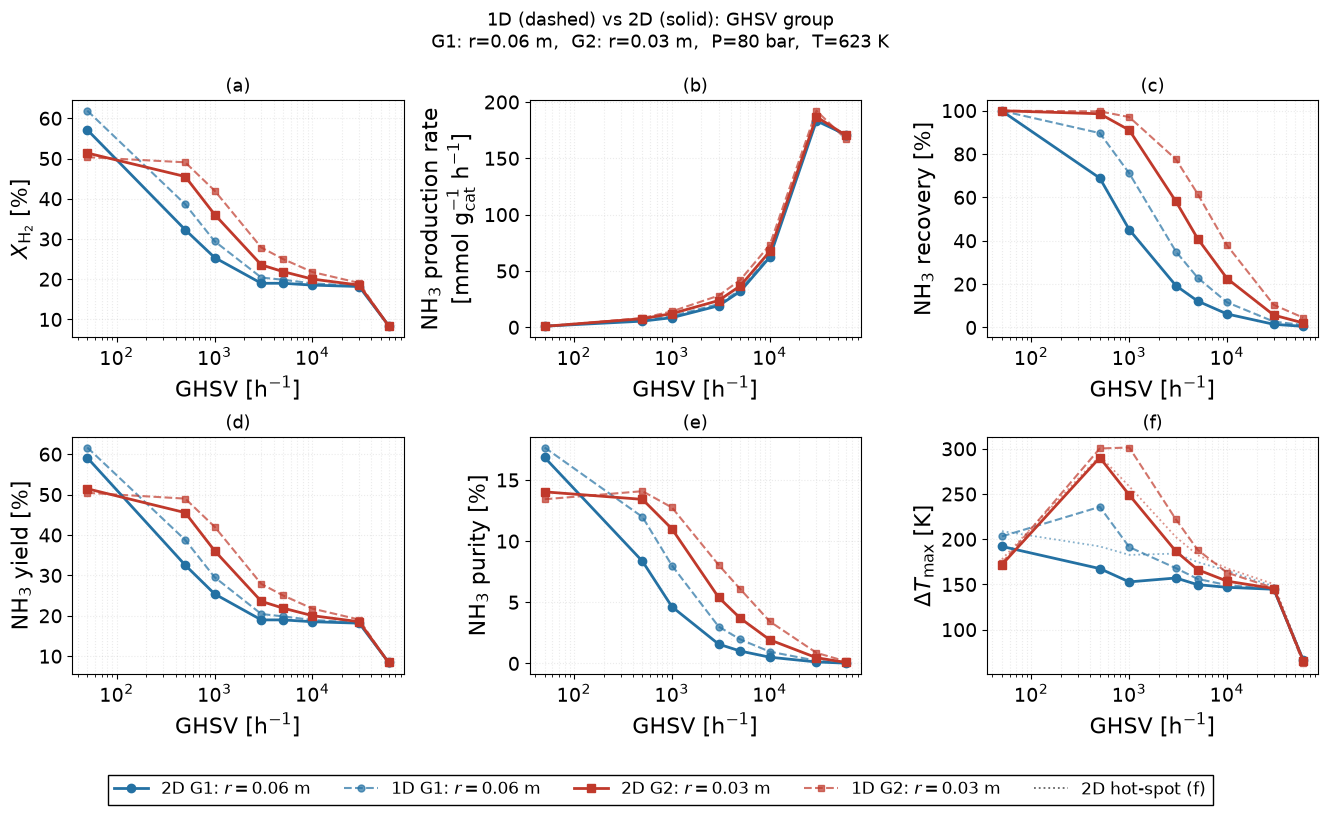

In [16]:
fig = figures.figure_6_whsv(summary_2d, summary_1d)
figures.save(fig, "fig06_1d2d_whsv", RESOLUTION)

[PosixPath('results/paper/draft/figures/fig07_1d2d_pressure.png'),
 PosixPath('results/paper/draft/figures/fig07_1d2d_pressure.pdf')]

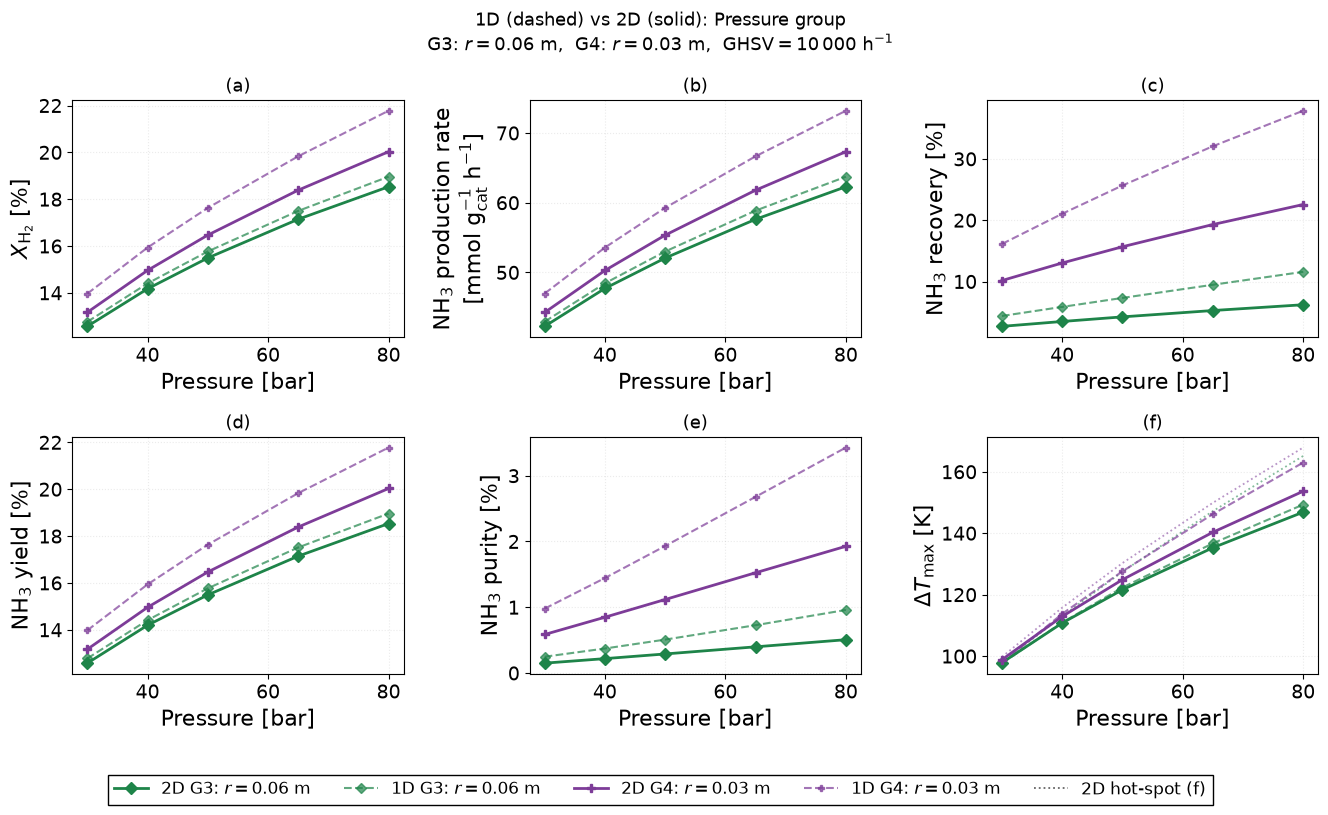

In [17]:
fig = figures.figure_7_pressure(summary_2d, summary_1d)
figures.save(fig, "fig07_1d2d_pressure", RESOLUTION)

[PosixPath('results/paper/draft/figures/fig08_1d2d_radius.png'),
 PosixPath('results/paper/draft/figures/fig08_1d2d_radius.pdf')]

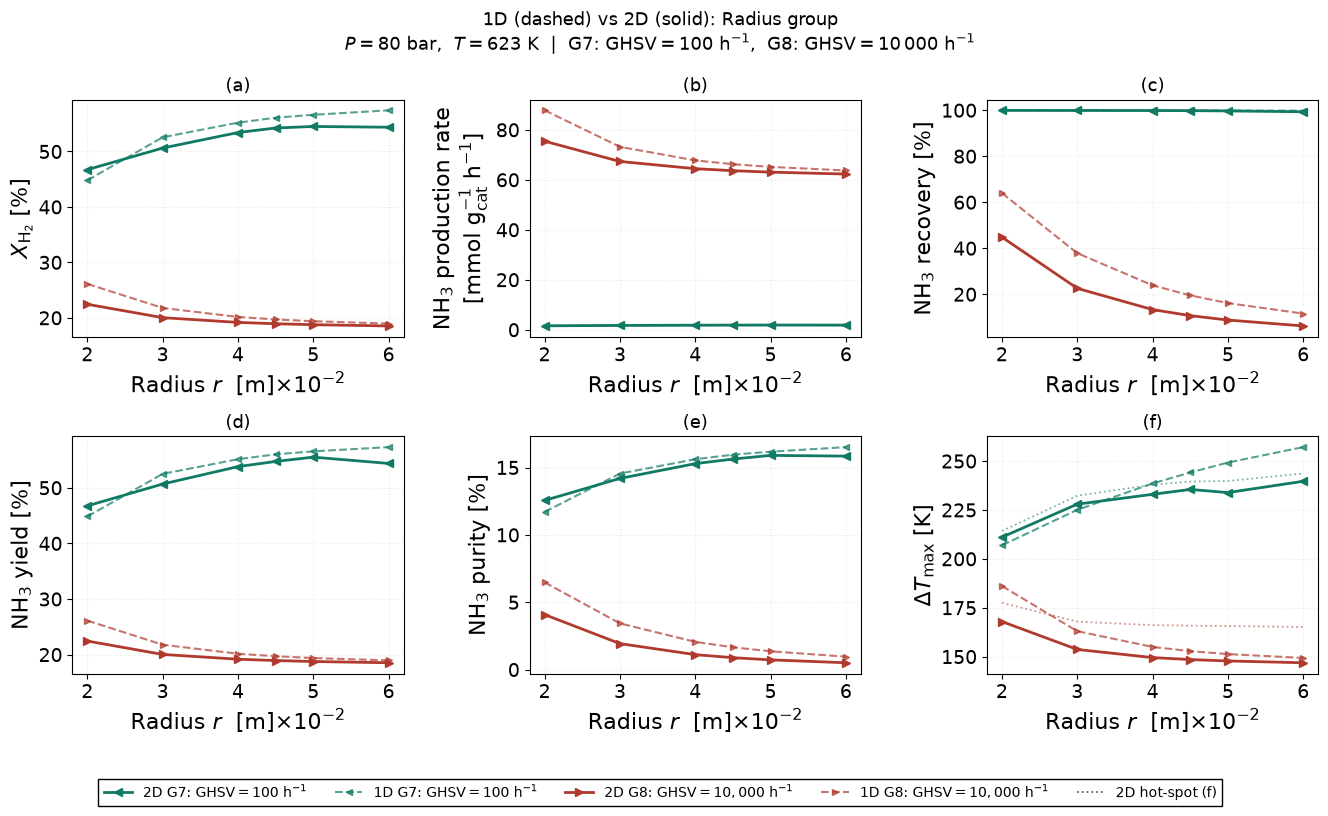

In [18]:
fig = figures.figure_8_radius(summary_2d, summary_1d)
figures.save(fig, "fig08_1d2d_radius", RESOLUTION)

## 6. Figures 9–11 — 2D fields and concentration-polarisation profiles

`CP_NH₃(z) = y_NH₃,wall(z) / ⟨y_NH₃(z)⟩`, the membrane-wall mole fraction over
the area-weighted cross-sectional mean. The 1D models assume `CP = 1`; these
figures are the direct evidence that it is not. The `CP_min` values in the
legends are computed from the data being plotted.

[PosixPath('results/paper/draft/figures/fig09_field_cp.png'),
 PosixPath('results/paper/draft/figures/fig09_field_cp.pdf')]

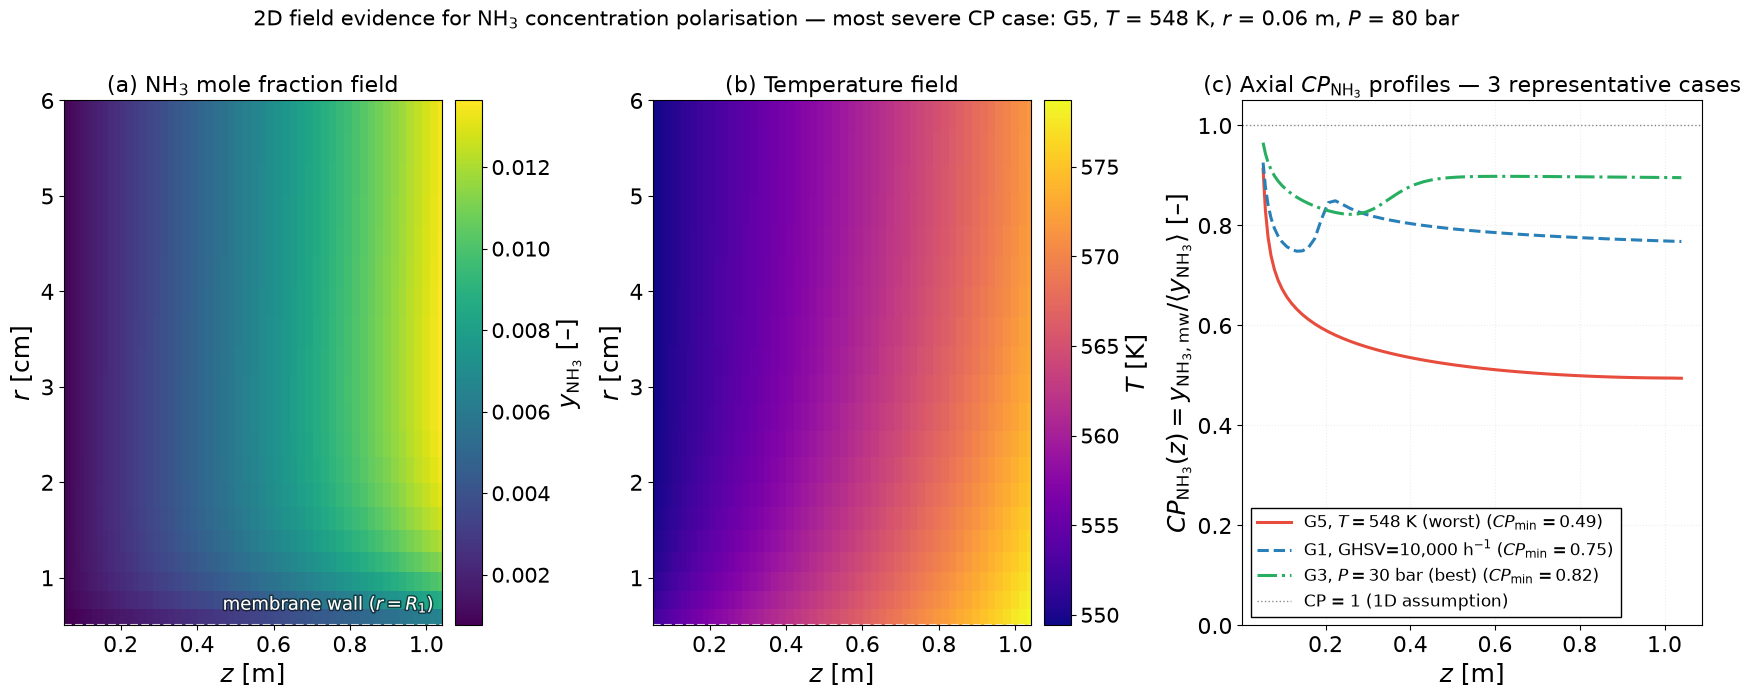

In [19]:
fig = figures.figure_9_field_cp(RESOLUTION)
figures.save(fig, "fig09_field_cp", RESOLUTION)

[PosixPath('results/paper/draft/figures/fig10_cp_pressure.png'),
 PosixPath('results/paper/draft/figures/fig10_cp_pressure.pdf')]

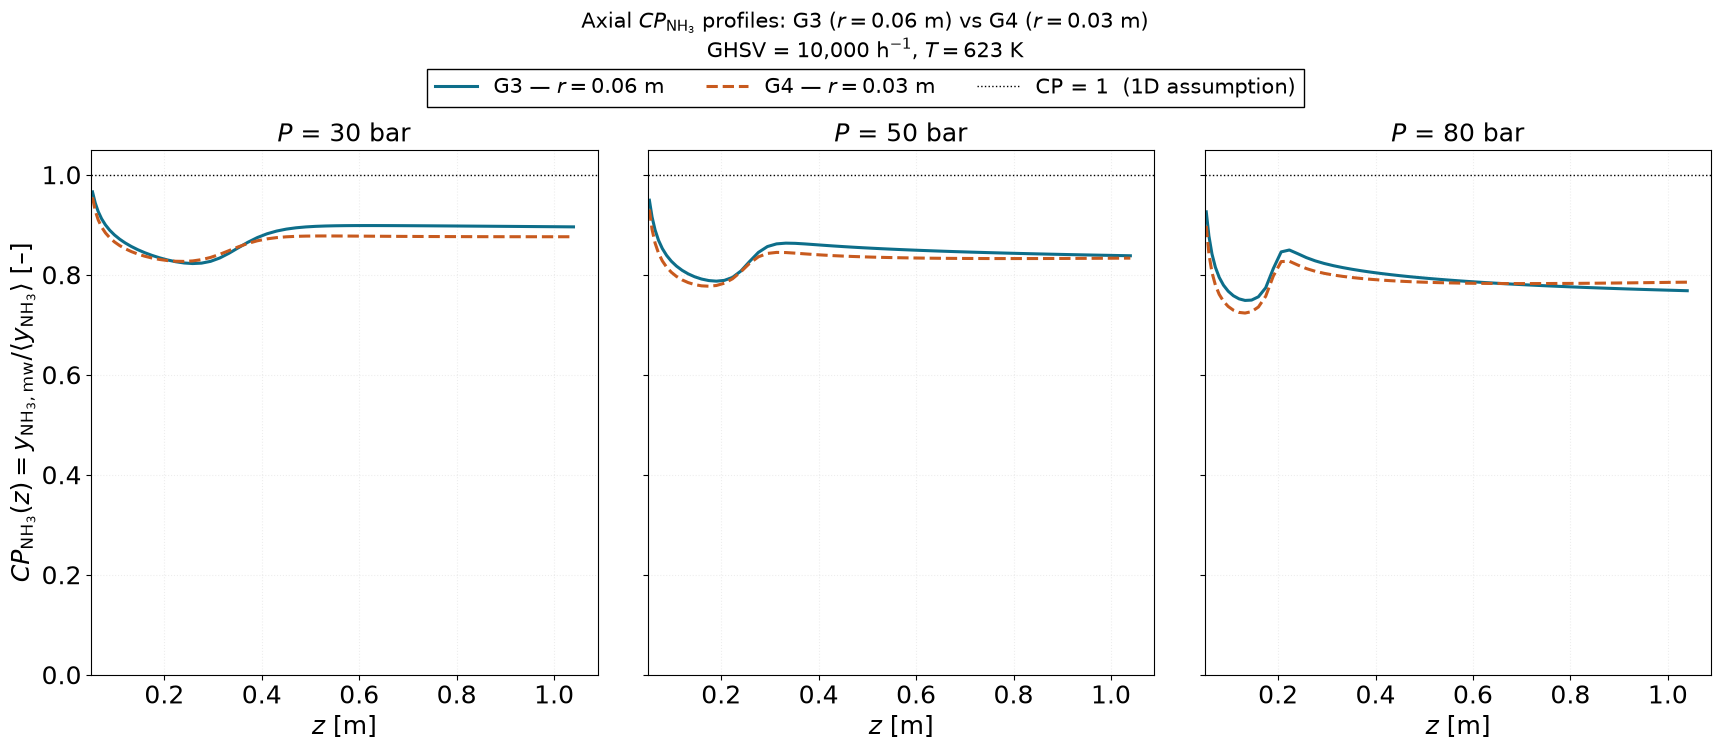

In [20]:
fig = figures.figure_10_cp_pressure(RESOLUTION)
figures.save(fig, "fig10_cp_pressure", RESOLUTION)

[PosixPath('results/paper/draft/figures/fig11_cp_radius.png'),
 PosixPath('results/paper/draft/figures/fig11_cp_radius.pdf')]

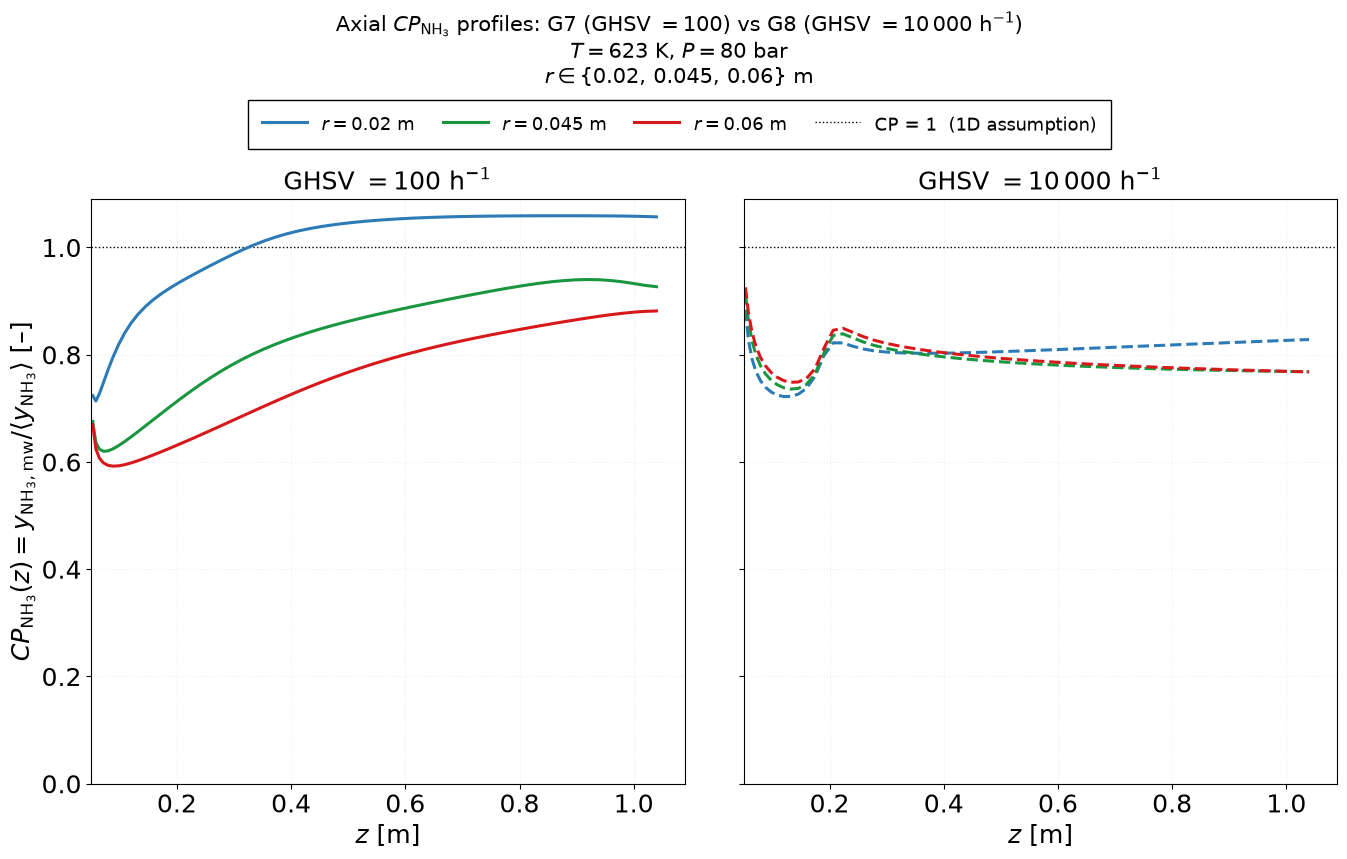

In [21]:
fig = figures.figure_11_cp_radius(RESOLUTION)
figures.save(fig, "fig11_cp_radius", RESOLUTION)

## 7. Figures 12–15 — Sherwood correlation, profiles, corrected CP

Layouts follow the manuscript figures (confirmed against the embedded
images of the manuscript draft), computed from the
certified cache:

* **Figure 12** — three panels: local wall-Sh vs $Re_{d_h}$ (Spearman
  independence, Poto/Wakao reference lines), both refit laws vs $\kappa$,
  and the $\kappa$-group medians ± IQR. The refit wall/film law
  (`sh_wall_fit.json`) replaces the manuscript's $Sh_{field}$; the
  flux-matched law (`sh_cp_fit.json`, what the corrected 1D consumes)
  replaces $Sh_{optimal}$.
* **Figure 13** — Re-independence of $Sh(z)$ at fixed $\kappa$ (G1/G2,
  colour = GHSV, classical annular band).
* **Figure 14** — the same profiles against the Graetz coordinate
  $z^* = D_m z/(u_z l_c^2)$ with the Lévêque and Graetz asymptotes.
* **Figure 15** — one representative case per $\kappa$ group with FOUR
  series: plain 1D (CP = 1), the 2D reference, and both corrected-1D
  variants ($Sh(\kappa)$ fit and mechanistic screening), each
  reconstructed from its own cached 1D solution; per-series MAE in the
  legend. Flux → wall translation uses the wall film law — the
  manuscript's CP definition.

[PosixPath('results/paper/draft/figures/fig12_sh_correlation.png'),
 PosixPath('results/paper/draft/figures/fig12_sh_correlation.pdf')]

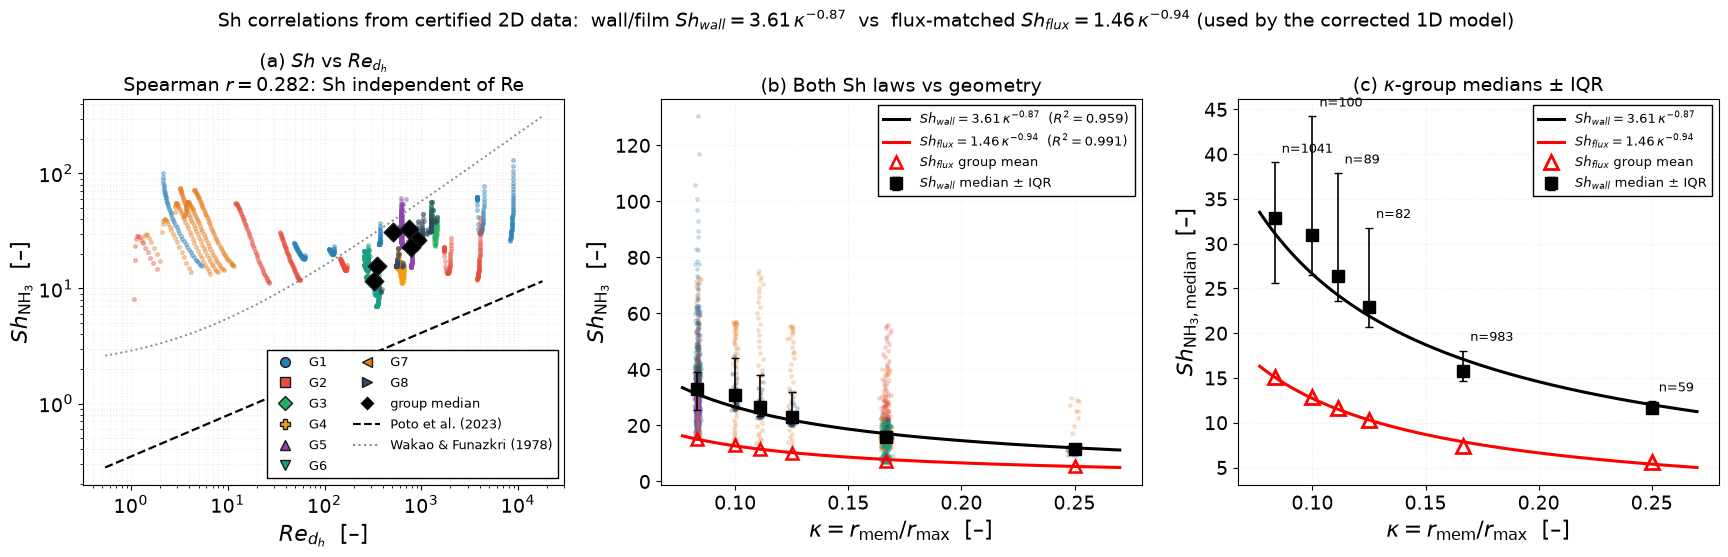

In [22]:
fig = figures.figure_12_sh_correlation(RESOLUTION, case_table)
figures.save(fig, "fig12_sh_correlation", RESOLUTION)

[PosixPath('results/paper/draft/figures/fig13_sh_whsv.png'),
 PosixPath('results/paper/draft/figures/fig13_sh_whsv.pdf')]

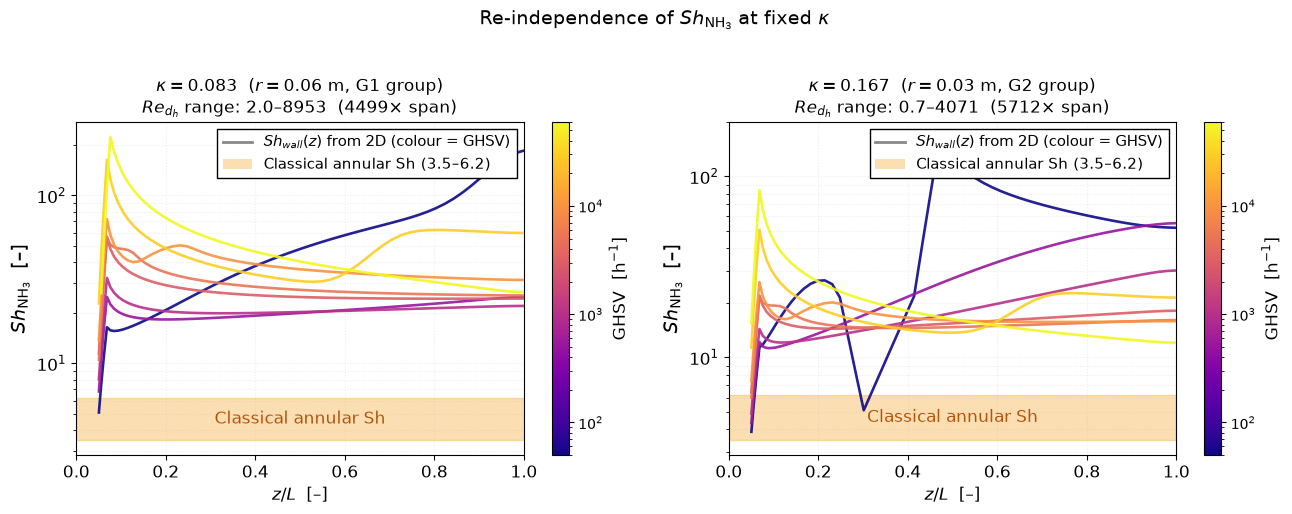

In [23]:
fig = figures.figure_13_sh_whsv(RESOLUTION, case_table)
figures.save(fig, "fig13_sh_whsv", RESOLUTION)

[PosixPath('results/paper/draft/figures/fig14_sh_graetz.png'),
 PosixPath('results/paper/draft/figures/fig14_sh_graetz.pdf')]

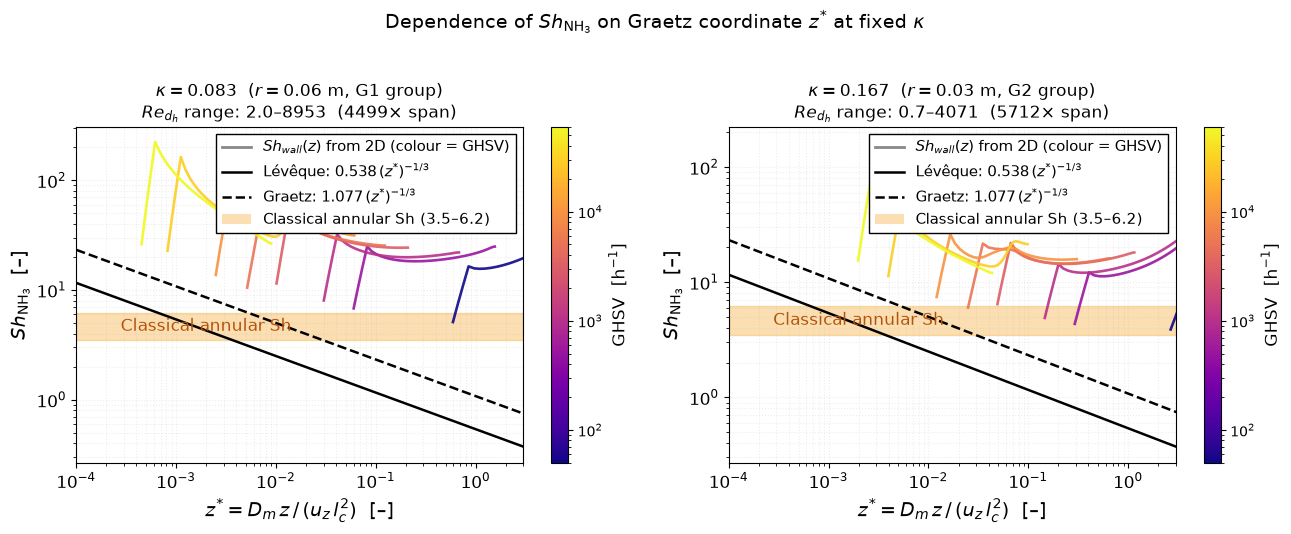

In [24]:
fig = figures.figure_14_sh_graetz(RESOLUTION, case_table)
figures.save(fig, "fig14_sh_graetz", RESOLUTION)

[PosixPath('results/paper/draft/figures/fig15_cp_kgroup.png'),
 PosixPath('results/paper/draft/figures/fig15_cp_kgroup.pdf')]

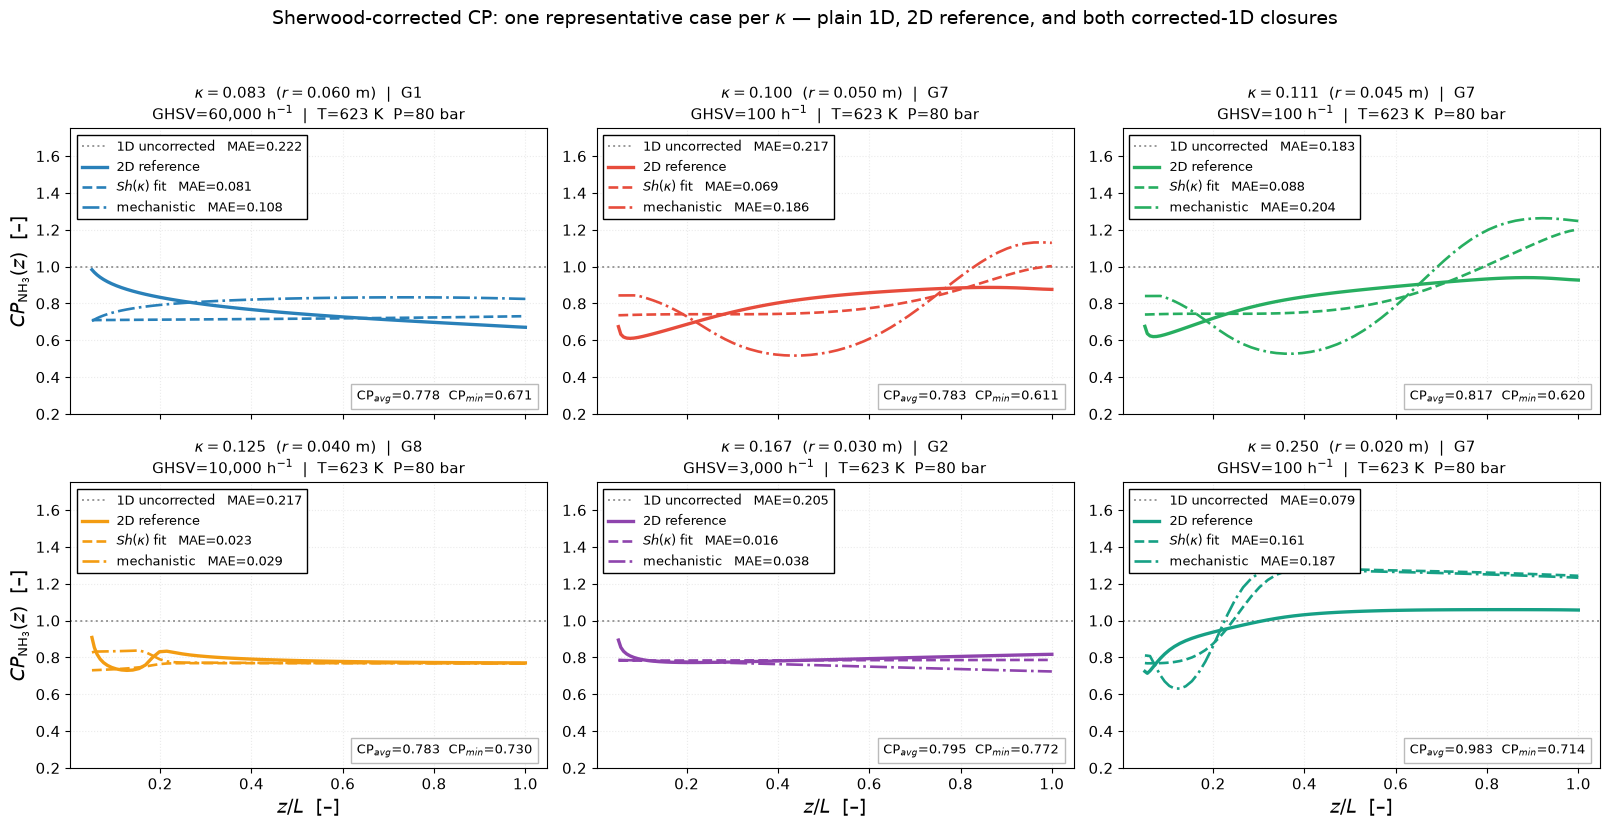

In [25]:
fig = figures.figure_15_cp_kgroup(RESOLUTION, case_table, summary_2d)
figures.save(fig, "fig15_cp_kgroup", RESOLUTION)

## 8b. Figure 16 — mechanistic validation of the CP closure

The reaction-screened closure (`reactor.cp_closure`, calibration in
`reactor.paper.closures`) evaluated per case with no geometry fit against
the exact flux-matched Sherwood numbers, plus the axial $k_{cp}$ profile of
a representative case. The exact-tracing decomposition and the deficit-layer
field measurements quoted in Section 3.3.3 regenerate from
`reactor.paper.mechanistic` (cached beside the KPI summaries).

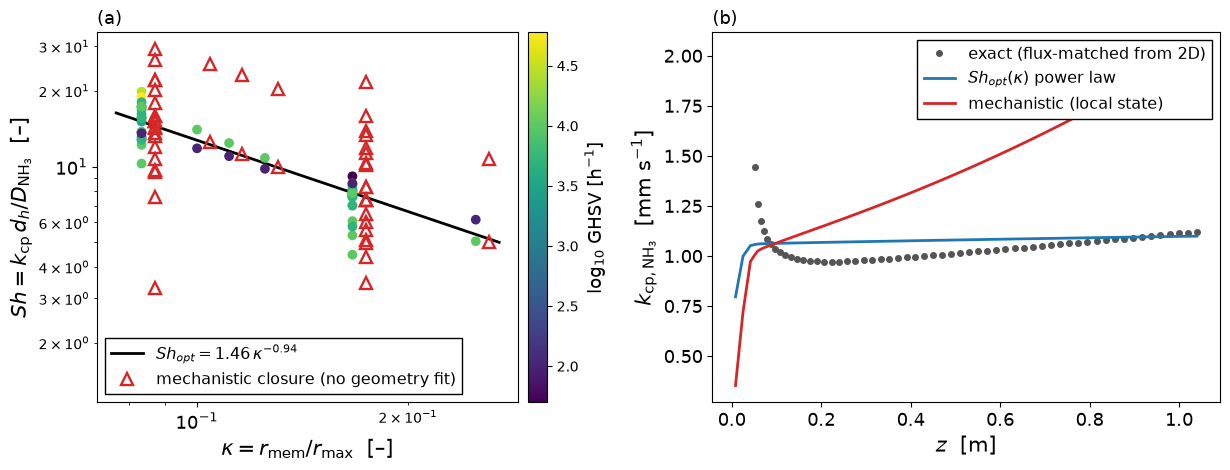

In [26]:
fig = figures.figure_16_mechanistic(RESOLUTION, case_table)
figures.save(fig, "fig16_mechanistic", RESOLUTION)

from reactor.paper import mechanistic
if mechanistic.exact_trace_path(RESOLUTION).exists():
    print("exact tracing:", mechanistic.exact_trace_summary(RESOLUTION))
if mechanistic.field_scan_path(RESOLUTION).exists():
    scan = mechanistic.field_scan(RESOLUTION)
    print("deficit layer [mm]:", scan["half_thickness_mm"],
          "| suction Pe:", scan["suction_peclet"])

## 8. Validation — Weisz–Prater (Figure 2) and Rossetti kinetics (Figures 3–4)

(`reactor.paper.validation`). Instead of a nominal inlet state, the scan
finds the worst local `|R_i| / (D_eff,i c_i)` per species over *every*
accepted cached 2D case — hot spots included — so the "internal gradients
negligible" claim is anchored to the actual operating envelope. Solid
curves use `D_eff = 0.1·D` (assumed ε_p/τ_p, **not measured** — flagged),
dotted the molecular-diffusivity bound. The NH₃ curve is evaluated at the
`y > 1e-3` floor and is therefore a conservative trace-region bound, not a
reactant limitation.

**Figures 3–4**: the runner half existed (`scripts/run_rossetti_1d.py`);
the plotting half is new. The published table runs the **2D model**
(24 radial cells, matching the manuscript's caption; the 1D table
agrees to ≤0.3 % and stays as a cross-check). Acceptance is by
KPI-drift certificate — same certificate-over-threshold discipline as
the paper sweeps. The 2D table is ~125 solves at ~200 s each; run it
once in the background (`run_rossetti(model="2d")`, shardable over
`tests`), after which this cell reads the CSV.

[PosixPath('results/paper/draft/figures/fig02_weisz_prater.png'),
 PosixPath('results/paper/draft/figures/fig02_weisz_prater.pdf')]

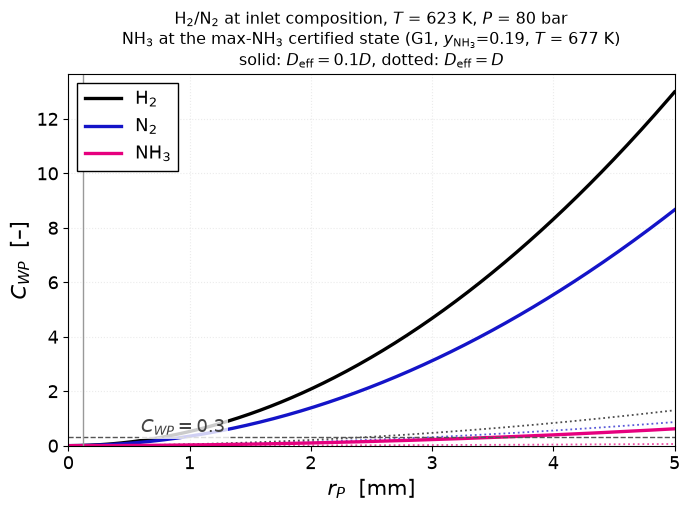

In [27]:
from reactor.paper import validation

scan = validation.weisz_prater_scan(case_table, RESOLUTION)
fig = figures.figure_2_weisz_prater(scan)
figures.save(fig, "fig02_weisz_prater", RESOLUTION)

125 experimental points, 125 KPI-drift certified


[PosixPath('results/paper/draft/figures/fig03_rossetti_ghsv.png'),
 PosixPath('results/paper/draft/figures/fig03_rossetti_ghsv.pdf')]

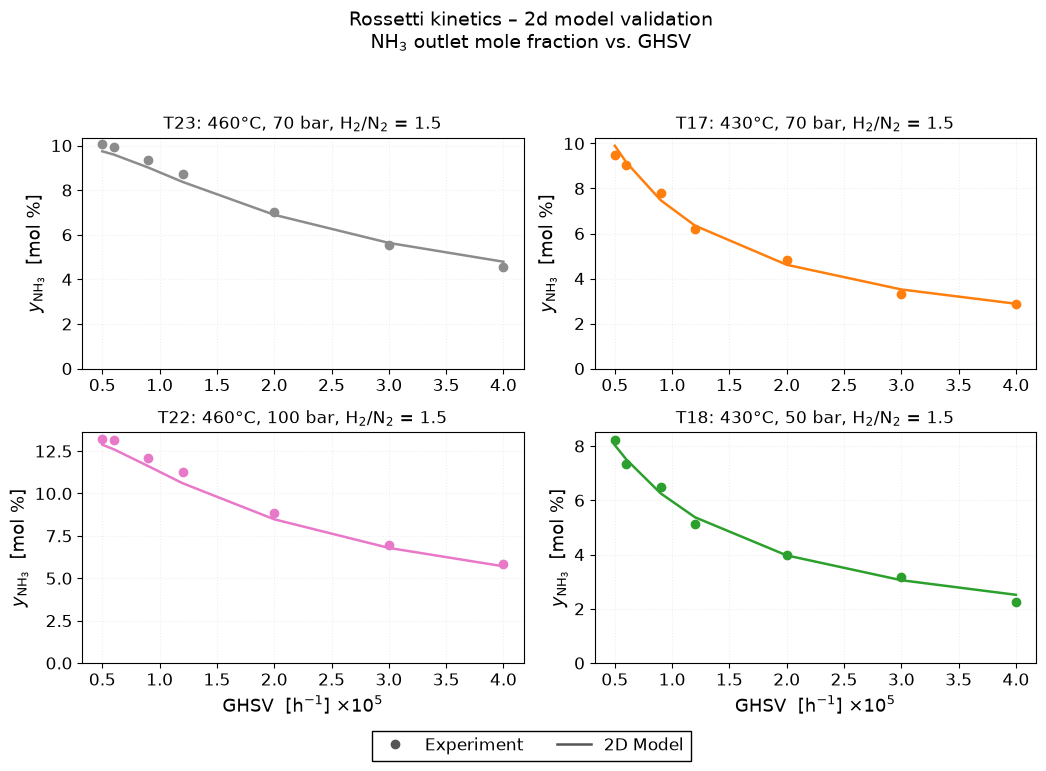

In [28]:
rossetti = validation.run_rossetti(model="2d")
n_ok = int(rossetti["solve_converged"].sum())
print(f"{len(rossetti)} experimental points, {n_ok} KPI-drift certified")
fig = figures.figure_3_rossetti_ghsv(rossetti)
figures.save(fig, "fig03_rossetti_ghsv", RESOLUTION)

[PosixPath('results/paper/draft/figures/fig04_rossetti_parity.png'),
 PosixPath('results/paper/draft/figures/fig04_rossetti_parity.pdf')]

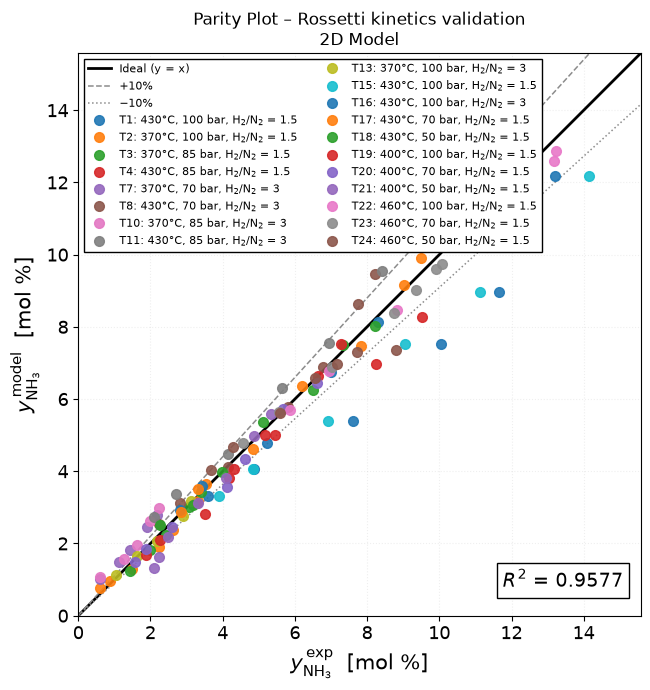

In [29]:
fig = figures.figure_4_rossetti_parity(rossetti)
figures.save(fig, "fig04_rossetti_parity", RESOLUTION)

### Relative error vs GHSV (diagnostic)

Model-bias diagnostic, not a manuscript figure: (Exp/Model − 1) per test
across GHSV with the ±10 % band. On the 2D table the systematic deviations
are: the model **over-predicts** the 370 °C / H₂:N₂ = 3 tests (T7, T10;
mean −26 %) and **under-predicts** the 430 °C / 100 bar tests (T1, T15;
mean +20–22 %); 62 % of all points fall within ±10 %.

[PosixPath('results/paper/draft/figures/fig_rossetti_relative_error.png'),
 PosixPath('results/paper/draft/figures/fig_rossetti_relative_error.pdf')]

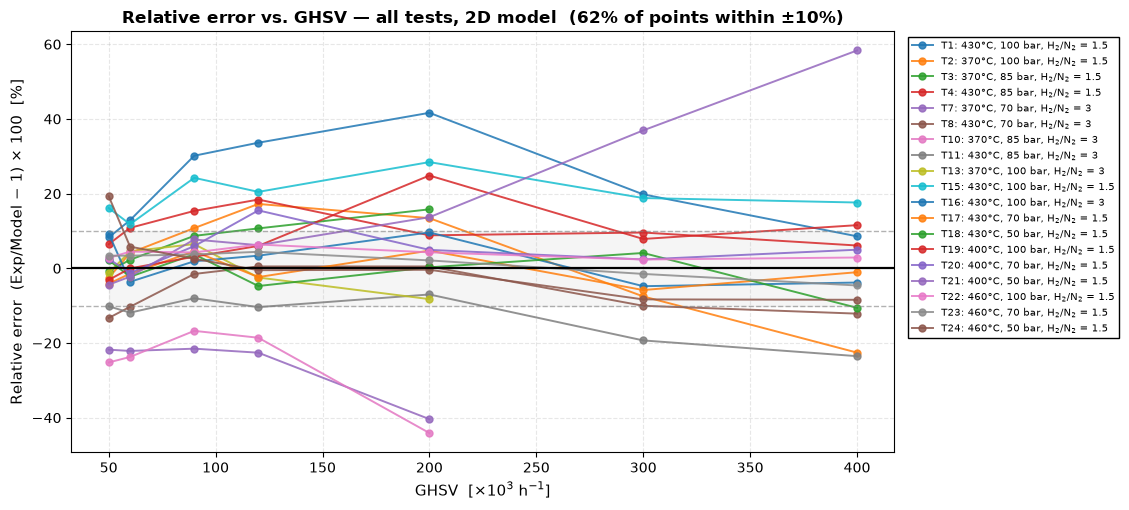

In [30]:
fig = figures.figure_rossetti_relative_error(rossetti)
figures.save(fig, "fig_rossetti_relative_error", RESOLUTION)

### Figure 5 — membrane permeance validation

Symbols: measured single-gas permeances of the CMS membrane (digitized from the
published figure, ~2 % read-off uncertainty; provenance in the CSV header —
`settings.PERMEATION_EXP_CSV` accepts the laboratory table directly). Line: the Arrhenius membrane sub-model used by the 2D
reactor, fitted to those points (NH₃ has a negative apparent activation
energy; the reactor's config keeps its *optimized target* permeances,
which differ for H₂/N₂ by design).

The 15-case permeation-module cross-check (LMDF read-out of the module
simulation; N₂ reproduces the law to 0.02 %, NH₃/H₂ read ~10 % low from the
end-point LMDF averaging) is still computed below as a code-level diagnostic,
but is no longer drawn in the paper figure — the manuscript text and caption
describe experiment and Arrhenius model only.

[PosixPath('results/paper/draft/figures/fig05_permeance.png'),
 PosixPath('results/paper/draft/figures/fig05_permeance.pdf')]

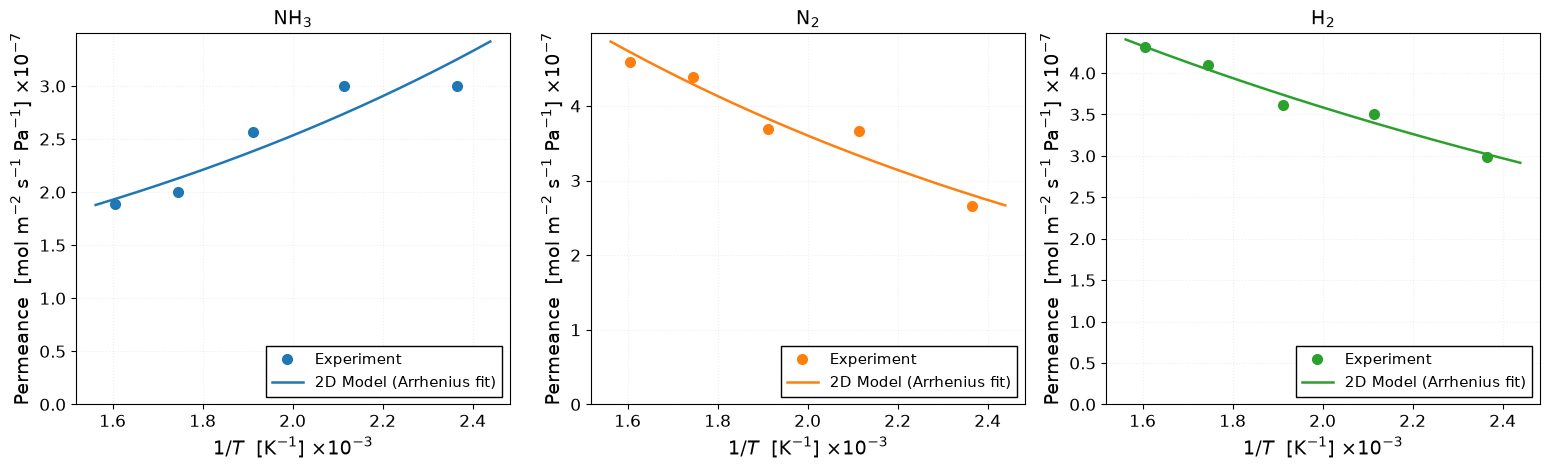

In [31]:
permeation_exp = validation.load_permeation_experiment()
permeation_fit = validation.fit_permeance_arrhenius()
permeation_module = validation.run_permeation()
fig = figures.figure_5_permeance(permeation_exp, permeation_fit)
figures.save(fig, "fig05_permeance", RESOLUTION)

## 9. Dataset export and manifest

`reactor.paper.dataset.export` assembles the archived-dataset payload out of
the cache — KPI summaries, per-case fields, closure fits, validation tables,
figures — and writes `manifest.json` with a SHA-256 checksum per file, the
git commit, package versions and wall times. `verify` re-hashes the tree
against the manifest, so a re-run of the pipeline can be compared against the
published dataset file by file.

The cell below is a **dry run by default**: it reports what would ship and
writes nothing. Set `EXPORT_DATASET = True` for a real export (publication
resolution, clean working tree).

In [32]:
from reactor.paper import dataset

EXPORT_DATASET = False   # final deposit export is a deliberate act

report = dataset.export(RESOLUTION, dry_run=not EXPORT_DATASET)
print(f"{report['n_files']} files, {report['total_bytes']/1e6:.1f} MB "
      f"-> {report['out_dir']}{'  (dry run)' if report['dry_run'] else ''}")
for gap in report["missing"]:
    print("  MISSING:", gap)
if EXPORT_DATASET:
    check = dataset.verify()
    assert check["ok"], check
    print(f"manifest verifies: {check['n_checked']} files")

1505 files, 23.9 MB -> dataset  (dry run)
  MISSING: closures/exact_trace_kpis.csv
  MISSING: closures/mech_field_scan.json
